In [1]:
# Libraries used
import pandas as pd                                # data handling and resampling
import numpy as np                                 # numeric utilities
import matplotlib.pyplot as plt                    # plotting
import seaborn as sns                              # nicer plot styles
from scipy import stats                          # statistical tests
from pathlib import Path                             # filesystem-safe paths
from statsmodels.graphics.tsaplots import plot_acf    # ACF plotting utility

## Data Loading & Cleaning

In [2]:
# 1. Load Excel file (update filename if different)
xlsx_path = Path("System_Data_Qtr_Hourly_2024.xlsx")  # path to the Excel file
raw = pd.read_excel(xlsx_path, engine="openpyxl")    # read the first sheet into a DataFrame
print(f"Loaded dataset with {len(raw)} rows and {len(raw.columns)} columns.")

Loaded dataset with 35136 rows and 10 columns.


In [3]:
#data check at first glance
print(raw.head(10))

             DateTime  GMT Offset  NI Generation  NI Demand  \
0 2024-01-01 00:00:00           0        715.613    584.635   
1 2024-01-01 00:15:00           0        702.913    570.701   
2 2024-01-01 00:30:00           0        799.801    563.575   
3 2024-01-01 00:45:00           0        877.653    562.830   
4 2024-01-01 01:00:00           0        872.636    577.349   
5 2024-01-01 01:15:00           0        793.143    578.898   
6 2024-01-01 01:30:00           0        705.061    568.297   
7 2024-01-01 01:45:00           0        628.018    557.111   
8 2024-01-01 02:00:00           0        605.511    548.984   
9 2024-01-01 02:15:00           0        589.968    537.511   

   NI Wind Generation  NI Solar Generation  IE Generation  IE Demand  \
0             249.907                  0.0        3123.41    3462.62   
1             216.946                  0.0        3127.56    3427.96   
2             301.445                  0.0        3138.09    3394.02   
3             376.

In [4]:
#checking datas satatistical summary
print(raw.describe(include='all'))

                            DateTime    GMT Offset  NI Generation  \
count                          35136  35136.000000   35136.000000   
mean   2024-07-02 00:26:55.573770496      0.573770     832.433968   
min              2024-01-01 00:00:00      0.000000     370.910000   
25%              2024-04-01 12:56:15      0.000000     674.059750   
50%              2024-07-02 00:52:30      1.000000     794.796500   
75%              2024-10-01 12:48:45      1.000000     961.820750   
max              2024-12-31 23:45:00      1.000000    1763.830000   
std                              NaN      0.494535     204.963170   

          NI Demand  NI Wind Generation  NI Solar Generation  IE Generation  \
count  35136.000000        35136.000000         35136.000000   35136.000000   
mean     821.918353          243.668994            11.777413    3286.691235   
min      410.257000            0.000000             0.000000    1767.270000   
25%      635.477250           79.193000             0.000000  

In [5]:
# 2. Preserve original columns for provenance
raw["DateTime_raw"] = raw["DateTime"]                # keep original timestamp string column
print("Preserved original DateTime column as DateTime_raw.")
print(raw["DateTime_raw"].head(10))
#checking the preserved column
print("\nChecking preserved DateTime_raw column:")
print(raw["DateTime_raw"].tail(10))

Preserved original DateTime column as DateTime_raw.
0   2024-01-01 00:00:00
1   2024-01-01 00:15:00
2   2024-01-01 00:30:00
3   2024-01-01 00:45:00
4   2024-01-01 01:00:00
5   2024-01-01 01:15:00
6   2024-01-01 01:30:00
7   2024-01-01 01:45:00
8   2024-01-01 02:00:00
9   2024-01-01 02:15:00
Name: DateTime_raw, dtype: datetime64[ns]

Checking preserved DateTime_raw column:
35126   2024-12-31 21:30:00
35127   2024-12-31 21:45:00
35128   2024-12-31 22:00:00
35129   2024-12-31 22:15:00
35130   2024-12-31 22:30:00
35131   2024-12-31 22:45:00
35132   2024-12-31 23:00:00
35133   2024-12-31 23:15:00
35134   2024-12-31 23:30:00
35135   2024-12-31 23:45:00
Name: DateTime_raw, dtype: datetime64[ns]


In [6]:
# 3. Parse DateTime to pandas datetime; coerce invalid strings to NaT
raw["DateTime_parsed"] = pd.to_datetime(raw["DateTime_raw"], errors="coerce")
print(raw.head(10))

             DateTime  GMT Offset  NI Generation  NI Demand  \
0 2024-01-01 00:00:00           0        715.613    584.635   
1 2024-01-01 00:15:00           0        702.913    570.701   
2 2024-01-01 00:30:00           0        799.801    563.575   
3 2024-01-01 00:45:00           0        877.653    562.830   
4 2024-01-01 01:00:00           0        872.636    577.349   
5 2024-01-01 01:15:00           0        793.143    578.898   
6 2024-01-01 01:30:00           0        705.061    568.297   
7 2024-01-01 01:45:00           0        628.018    557.111   
8 2024-01-01 02:00:00           0        605.511    548.984   
9 2024-01-01 02:15:00           0        589.968    537.511   

   NI Wind Generation  NI Solar Generation  IE Generation  IE Demand  \
0             249.907                  0.0        3123.41    3462.62   
1             216.946                  0.0        3127.56    3427.96   
2             301.445                  0.0        3138.09    3394.02   
3             376.

In [7]:
# 4. Normalize GMT Offset column name and coerce to numeric hours (allow for strings)
if "GMT Offset" in raw.columns:
    raw["GMT_Offset"] = pd.to_numeric(raw["GMT Offset"], errors="coerce")
# elif "GMT_Offset" in raw.columns:
#     raw["GMT_Offset"] = pd.to_numeric(raw["GMT_Offset"], errors="coerce")
else:
    raw["GMT_Offset"] = np.nan                         # create column if absent

In [8]:
# 5. Creating a local timestamp by applying GMT_Offset (hours) to parsed UTC DateTime when offset is present
# If DateTime_parsed is already local in the file, this will be a no-op when GMT_Offset is NaN
raw["timestamp_local"] = raw["DateTime_parsed"] + pd.to_timedelta(raw["GMT_Offset"].fillna(0), unit="h")
print(raw["timestamp_local"].tail(10))

35126   2024-12-31 21:30:00
35127   2024-12-31 21:45:00
35128   2024-12-31 22:00:00
35129   2024-12-31 22:15:00
35130   2024-12-31 22:30:00
35131   2024-12-31 22:45:00
35132   2024-12-31 23:00:00
35133   2024-12-31 23:15:00
35134   2024-12-31 23:30:00
35135   2024-12-31 23:45:00
Name: timestamp_local, dtype: datetime64[ns]


In [9]:
# 6. Where GMT_Offset missing, fall back to parsed DateTime (assumming it's already local)
raw.loc[raw["GMT_Offset"].isna(), "timestamp_local"] = raw.loc[raw["GMT_Offset"].isna(), "DateTime_parsed"]
print(raw["timestamp_local"].tail(15))

35121   2024-12-31 20:15:00
35122   2024-12-31 20:30:00
35123   2024-12-31 20:45:00
35124   2024-12-31 21:00:00
35125   2024-12-31 21:15:00
35126   2024-12-31 21:30:00
35127   2024-12-31 21:45:00
35128   2024-12-31 22:00:00
35129   2024-12-31 22:15:00
35130   2024-12-31 22:30:00
35131   2024-12-31 22:45:00
35132   2024-12-31 23:00:00
35133   2024-12-31 23:15:00
35134   2024-12-31 23:30:00
35135   2024-12-31 23:45:00
Name: timestamp_local, dtype: datetime64[ns]


In [10]:
# 7. Sort by the corrected local timestamp to ensure chronological order
raw = raw.sort_values("timestamp_local").reset_index(drop=True)
print("Data sorted by local timestamp.")
print(raw[["timestamp_local"]].tail(10))

Data sorted by local timestamp.
          timestamp_local
35126 2024-12-31 21:30:00
35127 2024-12-31 21:45:00
35128 2024-12-31 22:00:00
35129 2024-12-31 22:15:00
35130 2024-12-31 22:30:00
35131 2024-12-31 22:45:00
35132 2024-12-31 23:00:00
35133 2024-12-31 23:15:00
35134 2024-12-31 23:30:00
35135 2024-12-31 23:45:00


In [11]:
# 8. Set the corrected timestamp as a DatetimeIndex for time-based operations
raw.index = pd.DatetimeIndex(raw["timestamp_local"], name="timestamp_local")

In [12]:
# 9. Generate datetime features needed for analysis
raw["hour"] = raw.index.hour                          # hour of day 0-23
raw["date"] = raw.index.date                          # calendar date
raw["dayofweek"] = raw.index.dayofweek                # Monday=0 to Sunday=6
raw["month"] = raw.index.month                        # month 1-12
raw["year"] = raw.index.year                          # year

In [13]:
# 10. Basic missing-value audit: count NaNs per column
missing_counts = raw.isna().sum()                     # Series of missing counts per column
print("Missing values per column:")
print(missing_counts[missing_counts > 0])            # print no missing values only

Missing values per column:
Series([], dtype: int64)


In [14]:
# 11. Build expected full 15-minute index for continuity checks
expected_full_index = pd.date_range(start=raw.index.min(), end=raw.index.max(), freq="15min", name="timestamp_local")

In [15]:
# 12. Identify missing timestamps relative to expected 15-minute grid
missing_timestamps = expected_full_index.difference(raw.index)   # timestamps that are expected but missing
print(f"Detected {len(missing_timestamps)} missing timestamps in the expected 15-minute intervals.")


Detected 8 missing timestamps in the expected 15-minute intervals.


In [16]:
# 13. Detect duplicate timestamps (common during DST fall-back) and mark them
raw["is_duplicate_timestamp"] = raw.index.duplicated(keep=False)  # boolean flag for duplicates
n_duplicate_rows = int(raw["is_duplicate_timestamp"].sum())        # count of duplicate-index rows
print(f"Detected {n_duplicate_rows} duplicate timestamp rows.")

Detected 16 duplicate timestamp rows.


In [17]:
# 14. Compute consecutive time differences (in minutes) to find irregular gaps
time_deltas_min = raw.index.to_series().diff().dt.total_seconds().div(60)  # time delta between rows in minutes
irregular_gap_count = int((time_deltas_min.fillna(15) != 15).sum())       # count of deltas != 15


In [18]:
# 15. Identify expected non-negative measurement columns that should not be negative
expected_nonneg_cols = [
    "NI Generation", "NI Demand", "NI Wind Generation", "NI Solar Generation",
    "IE Generation", "IE Demand", "IE Wind Generation", "IE Solar Generation"
]
existing_nonneg_cols = [c for c in expected_nonneg_cols if c in raw.columns]  # keep only present columns
print(f"Checking non-negative constraints for columns: {existing_nonneg_cols}")

Checking non-negative constraints for columns: ['NI Generation', 'NI Demand', 'NI Wind Generation', 'NI Solar Generation', 'IE Generation', 'IE Demand', 'IE Wind Generation', 'IE Solar Generation']


In [19]:
# 16. For each numeric measurement column, coerce to numeric, flag negatives, and convert negatives to NaN
negatives_report = {}
for col in existing_nonneg_cols:
    numeric = pd.to_numeric(raw[col], errors="coerce")     # convert non-numeric to NaN
    neg_mask = numeric < 0                                 # boolean mask of negative values
    n_neg = int(neg_mask.sum())                            # count negatives
    sample_neg_ts = list(raw.index[neg_mask][:10])         # sample up to 10 timestamps with negative values
    negatives_report[col] = {"count_negative": n_neg, "example_timestamps": sample_neg_ts}
    raw[f"{col}_was_negative"] = neg_mask                  # mark rows that were negative
    raw[col] = numeric.mask(neg_mask, np.nan)              # replace negative values with NaN to avoid propagating errors

print(negatives_report)   

{'NI Generation': {'count_negative': 0, 'example_timestamps': []}, 'NI Demand': {'count_negative': 0, 'example_timestamps': []}, 'NI Wind Generation': {'count_negative': 0, 'example_timestamps': []}, 'NI Solar Generation': {'count_negative': 0, 'example_timestamps': []}, 'IE Generation': {'count_negative': 0, 'example_timestamps': []}, 'IE Demand': {'count_negative': 0, 'example_timestamps': []}, 'IE Wind Generation': {'count_negative': 0, 'example_timestamps': []}, 'IE Solar Generation': {'count_negative': 0, 'example_timestamps': []}}


In [20]:
# 17. Record missing-value summary and other cleaning diagnostics for reporting
cleaning_summary = {
    "n_rows": int(len(raw)),
    "missing_counts": missing_counts.to_dict(),
    "n_missing_timestamps_expected": int(len(missing_timestamps)),
    "n_duplicate_rows": n_duplicate_rows,
    "n_irregular_gaps": irregular_gap_count,
    "negatives_report": negatives_report
}
print(cleaning_summary)


{'n_rows': 35136, 'missing_counts': {'DateTime': 0, 'GMT Offset': 0, 'NI Generation': 0, 'NI Demand': 0, 'NI Wind Generation': 0, 'NI Solar Generation': 0, 'IE Generation': 0, 'IE Demand': 0, 'IE Wind Generation': 0, 'IE Solar Generation': 0, 'DateTime_raw': 0, 'DateTime_parsed': 0, 'GMT_Offset': 0, 'timestamp_local': 0, 'hour': 0, 'date': 0, 'dayofweek': 0, 'month': 0, 'year': 0}, 'n_missing_timestamps_expected': 8, 'n_duplicate_rows': 16, 'n_irregular_gaps': 9, 'negatives_report': {'NI Generation': {'count_negative': 0, 'example_timestamps': []}, 'NI Demand': {'count_negative': 0, 'example_timestamps': []}, 'NI Wind Generation': {'count_negative': 0, 'example_timestamps': []}, 'NI Solar Generation': {'count_negative': 0, 'example_timestamps': []}, 'IE Generation': {'count_negative': 0, 'example_timestamps': []}, 'IE Demand': {'count_negative': 0, 'example_timestamps': []}, 'IE Wind Generation': {'count_negative': 0, 'example_timestamps': []}, 'IE Solar Generation': {'count_negative':

In [21]:
# 18. Create cleaned_df for downstream analysis (no aggressive imputation performed)
cleaned_df = raw.copy()
DataFrame_cleaned=pd.DataFrame(cleaned_df)                                 # final cleaned dataset for later questions
print(DataFrame_cleaned)

                               DateTime  GMT Offset  NI Generation  NI Demand  \
timestamp_local                                                                 
2024-01-01 00:00:00 2024-01-01 00:00:00           0        715.613    584.635   
2024-01-01 00:15:00 2024-01-01 00:15:00           0        702.913    570.701   
2024-01-01 00:30:00 2024-01-01 00:30:00           0        799.801    563.575   
2024-01-01 00:45:00 2024-01-01 00:45:00           0        877.653    562.830   
2024-01-01 01:00:00 2024-01-01 01:00:00           0        872.636    577.349   
...                                 ...         ...            ...        ...   
2024-12-31 22:45:00 2024-12-31 22:45:00           0        734.862    601.169   
2024-12-31 23:00:00 2024-12-31 23:00:00           0        736.051    584.060   
2024-12-31 23:15:00 2024-12-31 23:15:00           0        737.141    570.368   
2024-12-31 23:30:00 2024-12-31 23:30:00           0        729.250    558.998   
2024-12-31 23:45:00 2024-12-

In [22]:
# 19.  Save cleaned dataset for reproducibility - commented out by default
cleaned_df.to_excel("System_Data_Qtr_Hourly_2025_cleaned.xlsx", index=True)

In [23]:
# finally the cleaned dataset asked
print("\nCLEANED DATASETS\n")
print(DataFrame_cleaned.head(10))


CLEANED DATASETS

                               DateTime  GMT Offset  NI Generation  NI Demand  \
timestamp_local                                                                 
2024-01-01 00:00:00 2024-01-01 00:00:00           0        715.613    584.635   
2024-01-01 00:15:00 2024-01-01 00:15:00           0        702.913    570.701   
2024-01-01 00:30:00 2024-01-01 00:30:00           0        799.801    563.575   
2024-01-01 00:45:00 2024-01-01 00:45:00           0        877.653    562.830   
2024-01-01 01:00:00 2024-01-01 01:00:00           0        872.636    577.349   
2024-01-01 01:15:00 2024-01-01 01:15:00           0        793.143    578.898   
2024-01-01 01:30:00 2024-01-01 01:30:00           0        705.061    568.297   
2024-01-01 01:45:00 2024-01-01 01:45:00           0        628.018    557.111   
2024-01-01 02:00:00 2024-01-01 02:00:00           0        605.511    548.984   
2024-01-01 02:15:00 2024-01-01 02:15:00           0        589.968    537.511   

        

## Monthly Statistics — IE & NI

In [24]:
# 1. Selecting and renaming columns we expect for clarity (use existing columns if present)
ie_cols = {
    "IE Demand": "IE_Demand",
    "IE Wind Generation": "IE_Wind",
    "IE Solar Generation": "IE_Solar"
}
ni_cols = {
    "NI Demand": "NI_Demand",
    "NI Wind Generation": "NI_Wind",
    "NI Solar Generation": "NI_Solar"
}

# 2. Keeping only columns that actually exist in cleaned_df to avoid KeyError
available_ie_cols = {k: v for k, v in ie_cols.items() if k in cleaned_df.columns}
available_ni_cols = {k: v for k, v in ni_cols.items() if k in cleaned_df.columns}

print(f"Available IE columns for analysis: {list(available_ie_cols.keys())}")
print(f"Available NI columns for analysis: {list(available_ni_cols.keys())}")



Available IE columns for analysis: ['IE Demand', 'IE Wind Generation', 'IE Solar Generation']
Available NI columns for analysis: ['NI Demand', 'NI Wind Generation', 'NI Solar Generation']


In [25]:
# 3. Create working DataFrame with timestamp index and required numeric columns coerced to float
work = cleaned_df.copy()                              # do not mutate original
for orig, new in {**available_ie_cols, **available_ni_cols}.items():
    # coerce non-numeric values to NaN and rename column
    work[new] = pd.to_numeric(work[orig], errors="coerce")

print(work[new].head(10))



timestamp_local
2024-01-01 00:00:00    0.0
2024-01-01 00:15:00    0.0
2024-01-01 00:30:00    0.0
2024-01-01 00:45:00    0.0
2024-01-01 01:00:00    0.0
2024-01-01 01:15:00    0.0
2024-01-01 01:30:00    0.0
2024-01-01 01:45:00    0.0
2024-01-01 02:00:00    0.0
2024-01-01 02:15:00    0.0
Name: NI_Solar, dtype: float64


In [26]:
# 4. a month column (integer 1-12) for grouping
work["month"] = work.index.month

# 5. aggregation function: mean, max, min (ignoring NaNs)
agg_funcs = ["mean", "max", "min"]


In [27]:
# 6. monthly statistics for Ireland (IE)
ie_monthly = work[list(available_ie_cols.values()) + ["month"]].groupby("month").agg(agg_funcs)
# Flatten MultiIndex columns to single-level with clear names: e.g., IE_Demand_mean
ie_monthly.columns = ["_".join(col).strip() for col in ie_monthly.columns.values]
ie_monthly = ie_monthly.sort_index()                 # ensure months in calendar order (1..12)
print(ie_monthly)

       IE_Demand_mean  IE_Demand_max  IE_Demand_min  IE_Wind_mean  \
month                                                               
1         4222.890017        5567.20        2848.01   1527.312396   
2         4057.178035        5174.38        2960.61   1698.879587   
3         4001.856267        5158.95        2978.53   1761.117315   
4         3794.158215        4805.38        2934.16   1271.525174   
5         3582.209432        4464.80        2740.76    735.103031   
6         3449.699660        4235.66        2661.65    883.560215   
7         3546.272241        4292.51        2677.64    765.451270   
8         3532.057241        4434.84        2645.70   1206.007739   
9         3695.073611        4619.12        2780.25   1078.389139   
10        3861.066371        5029.32        2891.87   1347.483871   
11        4180.054118        5690.90        3000.74   1206.895691   
12        4148.181452        5632.00        2826.37   1730.060390   

       IE_Wind_max  IE_Wind_min  

In [28]:


# 7. monthly statistics for Northern Ireland (NI)
ni_monthly = work[list(available_ni_cols.values()) + ["month"]].groupby("month").agg(agg_funcs)
ni_monthly.columns = ["_".join(col).strip() for col in ni_monthly.columns.values]
ni_monthly = ni_monthly.sort_index()
print(ni_monthly.head)

<bound method NDFrame.head of        NI_Demand_mean  NI_Demand_max  NI_Demand_min  NI_Wind_mean  \
month                                                               
1          940.092453       1452.952        476.913    327.045098   
2          897.000681       1368.026        463.011    333.578916   
3          854.394561       1264.124        485.295    314.688372   
4          813.188407       1189.161        431.686    225.655928   
5          776.154811       1075.974        452.746    159.885049   
6          746.288539       1050.722        443.318    188.553067   
7          735.066942       1041.917        468.829    117.513304   
8          724.909972       1034.622        423.839    229.823559   
9          772.296359       1116.200        449.091    185.551496   
10         827.232131       1248.478        410.257    289.519182   
11         904.993972       1448.573        455.228    243.423911   
12         874.676317       1438.695        432.607    310.416687   

   

In [29]:
# 8. Demand_mean, Demand_max, Demand_min, Wind_mean, Wind_max, Wind_min, Solar_mean, Solar_max, Solar_min
def tidy_table(monthly_df, prefix):
    # pick columns in expected order if they exist
    cols_order = []
    for var in ["Demand", "Wind", "Solar"]:
        base = f"{prefix}_{var}"
        for agg in ["mean", "max", "min"]:
            candidate = f"{base}_{agg}"
            if candidate in monthly_df.columns:
                cols_order.append(candidate)
    tidy = monthly_df[cols_order].copy()
    # rename columns to standardized short names
    rename_map = {}
    for c in tidy.columns:
        # e.g., IE_Demand_mean -> Demand_mean
        parts = c.split("_")
        rename_map[c] = "_".join(parts[1:])  # drop country prefix
    tidy = tidy.rename(columns=rename_map)
    # add month as a column for clearer display
    tidy = tidy.reset_index().rename(columns={"month": "Month"})
    tidy["Month"] = tidy["Month"].astype(int)
    return tidy

ie_tidy = tidy_table(ie_monthly, "IE")
ni_tidy = tidy_table(ni_monthly, "NI")

print("\nIreland Monthly Summary:\n")
print(ie_tidy)
print("\nNorthern Ireland Monthly Summary:\n")
print(ni_tidy)


Ireland Monthly Summary:

    Month  Demand_mean  Demand_max  Demand_min    Wind_mean  Wind_max  \
0       1  4222.890017     5567.20     2848.01  1527.312396   3769.27   
1       2  4057.178035     5174.38     2960.61  1698.879587   3602.16   
2       3  4001.856267     5158.95     2978.53  1761.117315   3801.51   
3       4  3794.158215     4805.38     2934.16  1271.525174   3382.66   
4       5  3582.209432     4464.80     2740.76   735.103031   2875.84   
5       6  3449.699660     4235.66     2661.65   883.560215   2871.50   
6       7  3546.272241     4292.51     2677.64   765.451270   2919.00   
7       8  3532.057241     4434.84     2645.70  1206.007739   2938.46   
8       9  3695.073611     4619.12     2780.25  1078.389139   3463.07   
9      10  3861.066371     5029.32     2891.87  1347.483871   3430.31   
10     11  4180.054118     5690.90     3000.74  1206.895691   3695.85   
11     12  4148.181452     5632.00     2826.37  1730.060390   3718.04   

    Wind_min  Solar_mea

## Daily & Weekly Demand vs Generation Trends

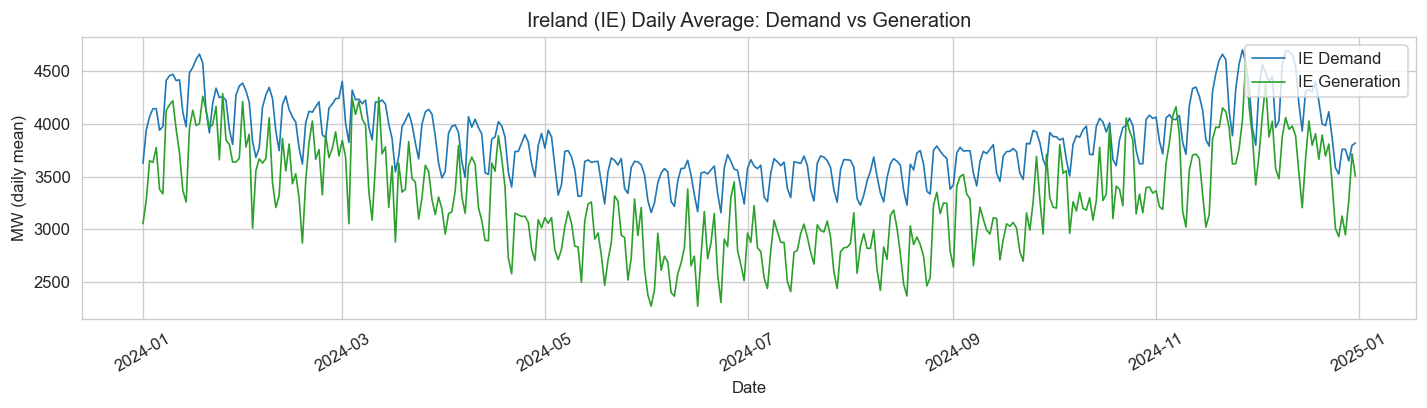

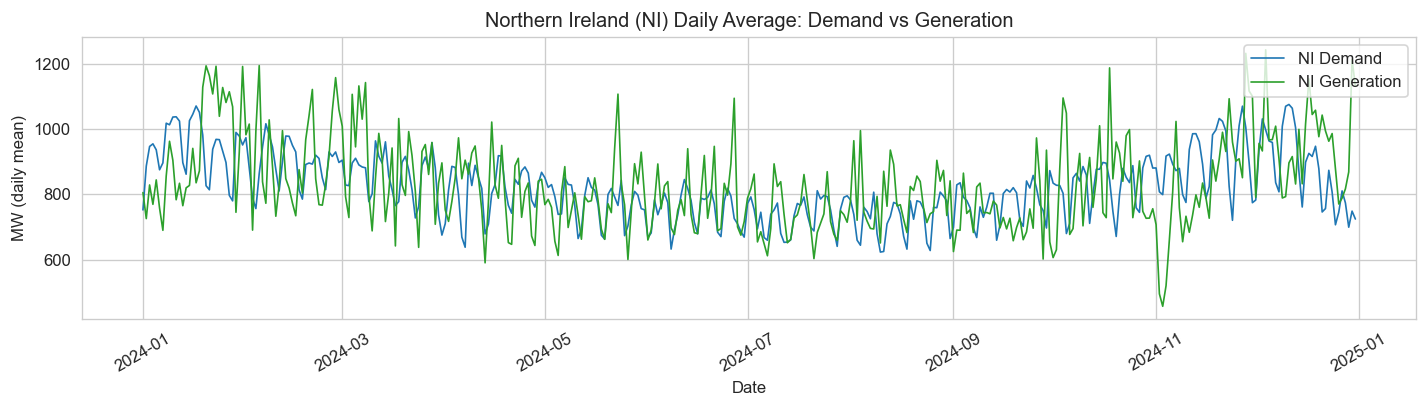

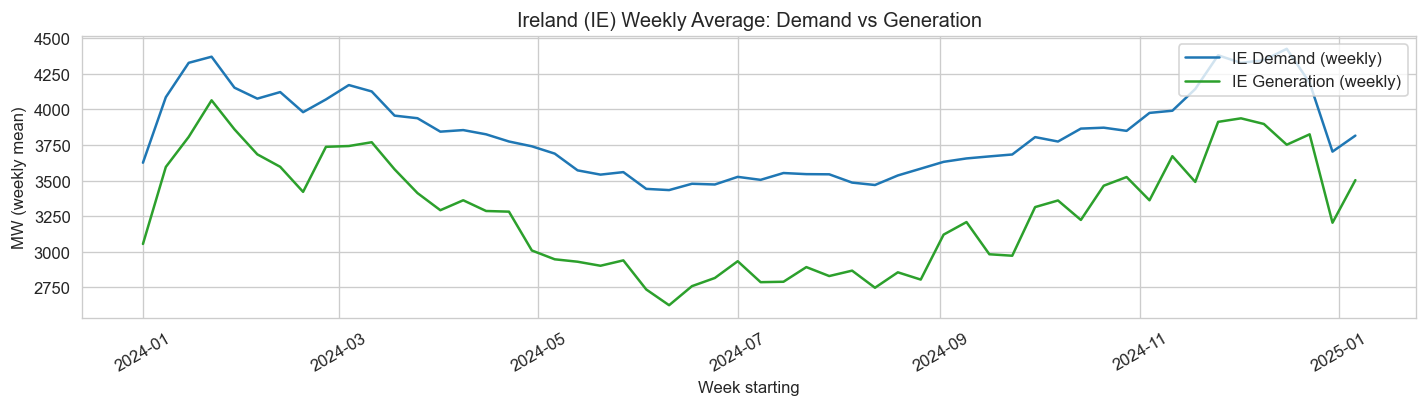

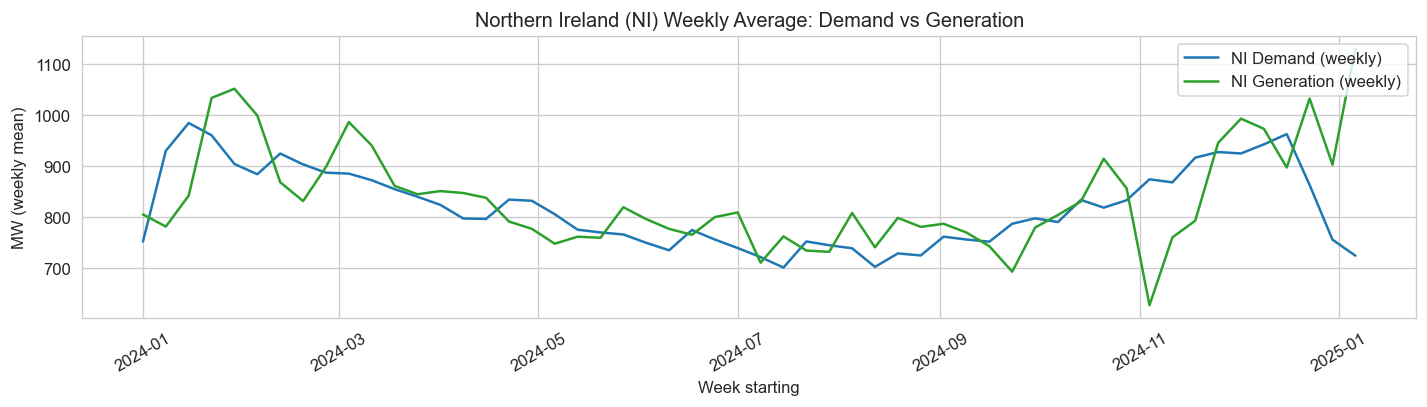

(                   IE_Demand  IE_Generation
 timestamp_local                            
 2024-01-01       3625.794583    3055.476458
 2024-01-02       3939.498021    3277.537917,
                   NI_Demand  NI_Generation
 timestamp_local                           
 2024-01-01       751.992188     805.075240
 2024-01-02       886.347000     725.345521,
                    IE_Demand  IE_Generation
 timestamp_local                            
 2024-01-01       3625.794583    3055.476458
 2024-01-08       4085.827277    3596.117872,
                   NI_Demand  NI_Generation
 timestamp_local                           
 2024-01-01       751.992188     805.075240
 2024-01-08       930.263195     781.320503)

In [30]:
# 1. Creating a working copy to avoid mutating the original cleaned_df
df = cleaned_df.copy()                              # local alias for clarity

# 2. Ensuring the key numeric columns exist and are numeric; coerce errors to NaN
cols_map = {
    "IE Demand": "IE_Demand",
    "IE Generation": "IE_Generation",
    "IE Wind Generation": "IE_Wind",
    "IE Solar Generation": "IE_Solar",
    "NI Demand": "NI_Demand",
    "NI Generation": "NI_Generation",
    "NI Wind Generation": "NI_Wind",
    "NI Solar Generation": "NI_Solar"
}
for orig, new in cols_map.items():
    if orig in df.columns:
        df[new] = pd.to_numeric(df[orig], errors="coerce")  # convert strings to numeric; NaN where invalid

# 3. Selection of  the main series we will average: Demand and Total Generation for IE and NI
# Prefering an explicit columns; if 'IE Generation' or 'NI Generation' missing, compute as sum of dispatchable + renewables if available
if "IE_Generation" not in df.columns and {"IE_Wind", "IE_Solar"}.issubset(df.columns):
    df["IE_Generation"] = df[["IE_Wind", "IE_Solar"]].sum(axis=1)  # fallback sum
if "NI_Generation" not in df.columns and {"NI_Wind", "NI_Solar"}.issubset(df.columns):
    df["NI_Generation"] = df[["NI_Wind", "NI_Solar"]].sum(axis=1)  # fallback sum

# 4. Resample to daily averages (mean) for Demand and Generation
ie_daily = df[["IE_Demand", "IE_Generation"]].resample("D").mean()  # daily mean for Ireland
ni_daily = df[["NI_Demand", "NI_Generation"]].resample("D").mean()  # daily mean for Northern Ireland

# 5. Resample to weekly averages (mean) for Demand and Generation
ie_weekly = df[["IE_Demand", "IE_Generation"]].resample("W-MON").mean()  # weekly mean, weeks starting Monday
ni_weekly = df[["NI_Demand", "NI_Generation"]].resample("W-MON").mean()  # same for NI

# 6. Ploting styling
sns.set_style("whitegrid")                           # sseaborn style for readability
plt.rcParams["figure.dpi"] = 120                    # reasonable resolution for notebook

# 7. Figure 1: IE daily time series - Demand and Generation
fig, ax = plt.subplots(figsize=(12, 3.5))           # create a wide figure for the daily IE series
ax.plot(ie_daily.index, ie_daily["IE_Demand"], label="IE Demand", color="tab:blue", linewidth=1)
ax.plot(ie_daily.index, ie_daily["IE_Generation"], label="IE Generation", color="tab:green", linewidth=1)
ax.set_title("Ireland (IE) Daily Average: Demand vs Generation")
ax.set_xlabel("Date")
ax.set_ylabel("MW (daily mean)")
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# 8. Figure 2: NI daily time series - Demand and Generation
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(ni_daily.index, ni_daily["NI_Demand"], label="NI Demand", color="tab:blue", linewidth=1)
ax.plot(ni_daily.index, ni_daily["NI_Generation"], label="NI Generation", color="tab:green", linewidth=1)
ax.set_title("Northern Ireland (NI) Daily Average: Demand vs Generation")
ax.set_xlabel("Date")
ax.set_ylabel("MW (daily mean)")
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# 9. Figure 3: IE weekly time series - Demand and Generation
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(ie_weekly.index, ie_weekly["IE_Demand"], label="IE Demand (weekly)", color="tab:blue", linewidth=1.5)
ax.plot(ie_weekly.index, ie_weekly["IE_Generation"], label="IE Generation (weekly)", color="tab:green", linewidth=1.5)
ax.set_title("Ireland (IE) Weekly Average: Demand vs Generation")
ax.set_xlabel("Week starting")
ax.set_ylabel("MW (weekly mean)")
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# 10. Figure 4: NI weekly time series - Demand and Generation
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(ni_weekly.index, ni_weekly["NI_Demand"], label="NI Demand (weekly)", color="tab:blue", linewidth=1.5)
ax.plot(ni_weekly.index, ni_weekly["NI_Generation"], label="NI Generation (weekly)", color="tab:green", linewidth=1.5)
ax.set_title("Northern Ireland (NI) Weekly Average: Demand vs Generation")
ax.set_xlabel("Week starting")
ax.set_ylabel("MW (weekly mean)")
ax.legend(loc="upper right")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# 11. Export the computed series for reporting convenience (variables available in the notebook)
ie_daily.head(2), ni_daily.head(2), ie_weekly.head(2), ni_weekly.head(2)


## Autocorrelation of Wind & Solar Generation

In [31]:
# Create local working copy and coerce the four series to numeric
df = cleaned_df.copy()
df["NI_Wind"] = pd.to_numeric(df.get("NI Wind Generation", df.get("NI_Wind", np.nan)), errors="coerce")
df["NI_Solar"] = pd.to_numeric(df.get("NI Solar Generation", df.get("NI_Solar", np.nan)), errors="coerce")
df["IE_Wind"] = pd.to_numeric(df.get("IE Wind Generation", df.get("IE_Wind", np.nan)), errors="coerce")
df["IE_Solar"] = pd.to_numeric(df.get("IE Solar Generation", df.get("IE_Solar", np.nan)), errors="coerce")

# Define maximum lag in terms of 15-minute samples: 10 days * 24 hours/day * 4 samples/hour = 960 lags
max_lags = 10 * 24 * 4  # 960

# Helper to prepare a series: drop NaNs and (optionally) subtract mean to center the series
def prepare_series(series):
    s = series.dropna().astype(float)
    if len(s) == 0:
        return s
    return s - s.mean()

# Prepare each series
ni_wind = prepare_series(df["NI_Wind"])
ni_solar = prepare_series(df["NI_Solar"])
ie_wind = prepare_series(df["IE_Wind"])
ie_solar = prepare_series(df["IE_Solar"])

<Figure size 1200x432 with 0 Axes>

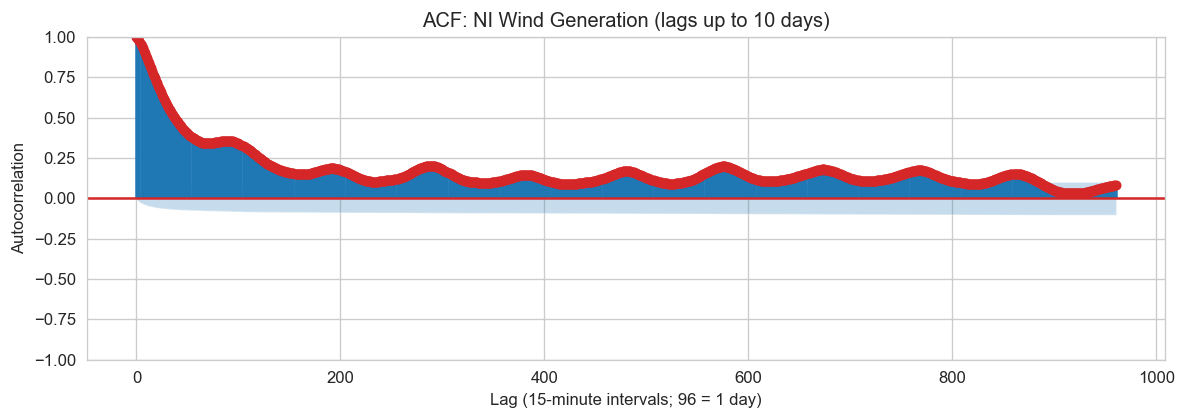

<Figure size 1200x432 with 0 Axes>

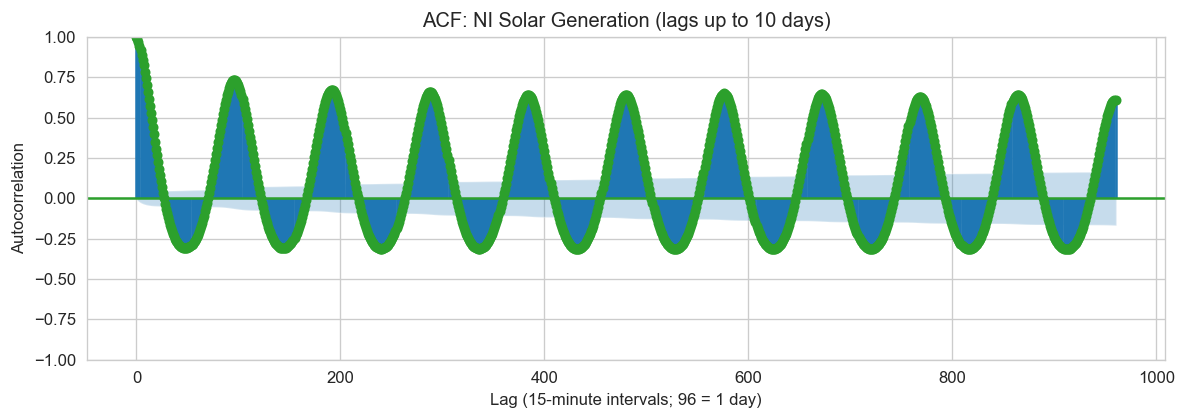

<Figure size 1200x432 with 0 Axes>

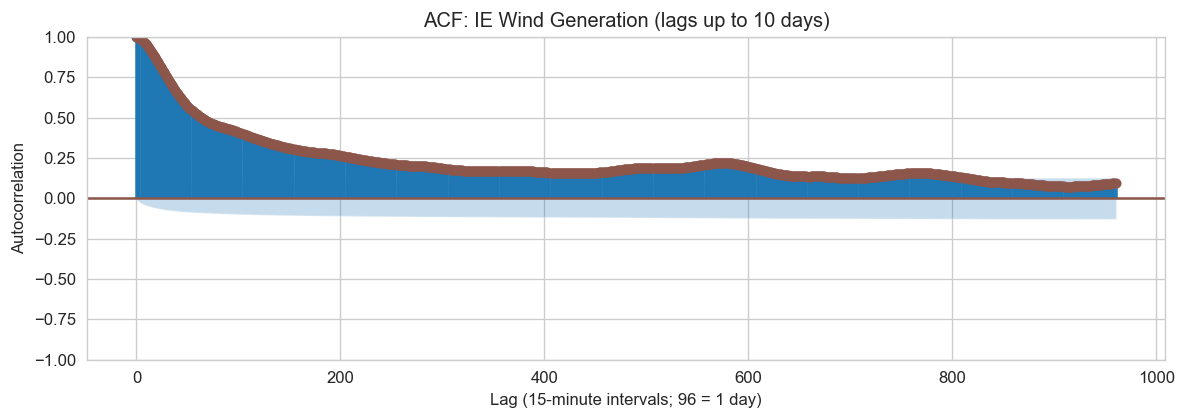

<Figure size 1200x432 with 0 Axes>

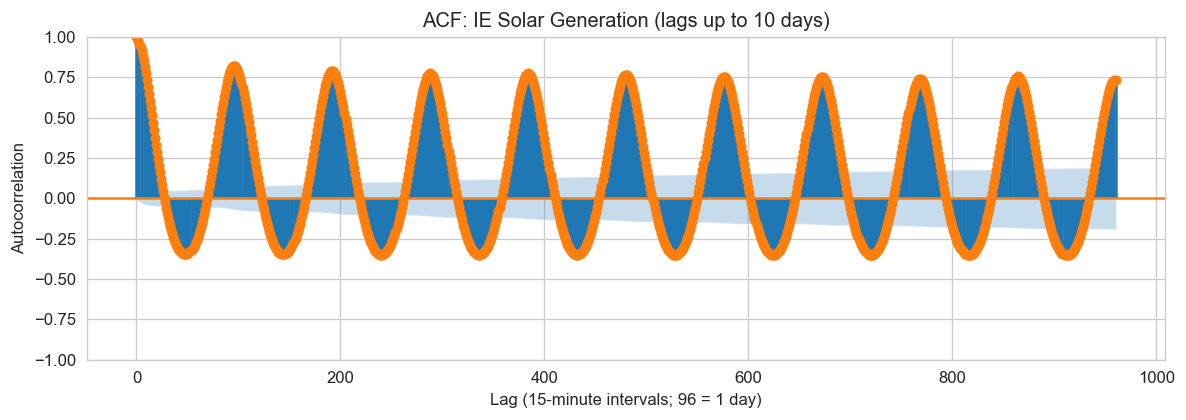

In [32]:
# Plot settings
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 3.6)

# 1) ACF for NI Wind Generation
plt.figure()
plot_acf(ni_wind, lags=max_lags, alpha=0.05, zero=True, color="tab:red")
plt.title("ACF: NI Wind Generation (lags up to 10 days)")
plt.xlabel("Lag (15-minute intervals; 96 = 1 day)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

# 2) ACF for NI Solar Generation
plt.figure()
plot_acf(ni_solar, lags=max_lags, alpha=0.05, zero=True, color="tab:green")
plt.title("ACF: NI Solar Generation (lags up to 10 days)")
plt.xlabel("Lag (15-minute intervals; 96 = 1 day)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

# 3) ACF for IE Wind Generation
plt.figure()
plot_acf(ie_wind, lags=max_lags, alpha=0.05, zero=True, color="tab:brown")
plt.title("ACF: IE Wind Generation (lags up to 10 days)")
plt.xlabel("Lag (15-minute intervals; 96 = 1 day)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

# 4) ACF for IE Solar Generation
plt.figure()
plot_acf(ie_solar, lags=max_lags, alpha=0.05, zero=True, color="tab:orange")
plt.title("ACF: IE Solar Generation (lags up to 10 days)")
plt.xlabel("Lag (15-minute intervals; 96 = 1 day)")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()


## Monthly Average Demand & Generation by Region

In [33]:
df = cleaned_df.copy()                               # work on a copy to avoid mutating original

# Ensuring numeric columns exist and coerce to numeric
df["NI_Demand"] = pd.to_numeric(df.get("NI Demand", df.get("NI_Demand", np.nan)), errors="coerce")
df["NI_Generation"] = pd.to_numeric(df.get("NI Generation", df.get("NI_Generation", np.nan)), errors="coerce")
#  month column for grouping (1..12)
df["month"] = df.index.month
# Computing monthly averages (mean) for NI: Demand and Generation
ni_monthly_avg = df.groupby("month")[["NI_Demand", "NI_Generation"]].mean().reindex(range(1,13))
ni_monthly_avg.index.name = "Month"


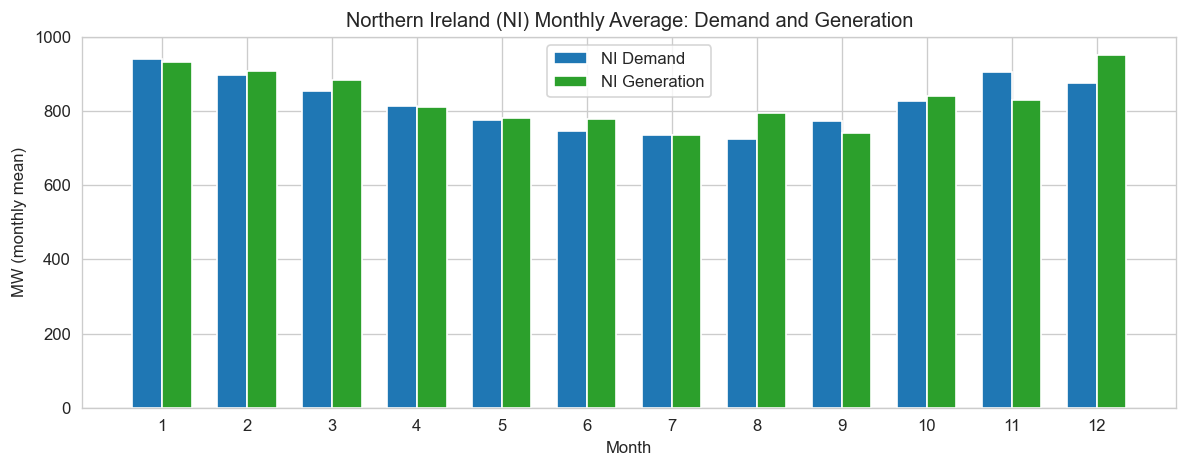

In [34]:
# Plot 1: NI monthly average Demand and Generation (side-by-side bars)
plt.rcParams["figure.dpi"] = 120
fig, ax = plt.subplots(figsize=(10,4))
width = 0.35                                         # bar width
months = ni_monthly_avg.index
ax.bar(months - width/2, ni_monthly_avg["NI_Demand"], width=width, label="NI Demand", color="tab:blue")
ax.bar(months + width/2, ni_monthly_avg["NI_Generation"], width=width, label="NI Generation", color="tab:green")
ax.set_xticks(months)
ax.set_xticklabels([str(m) for m in months])
ax.set_xlabel("Month")
ax.set_ylabel("MW (monthly mean)")
ax.set_title("Northern Ireland (NI) Monthly Average: Demand and Generation")
ax.legend()
plt.tight_layout()
plt.show()

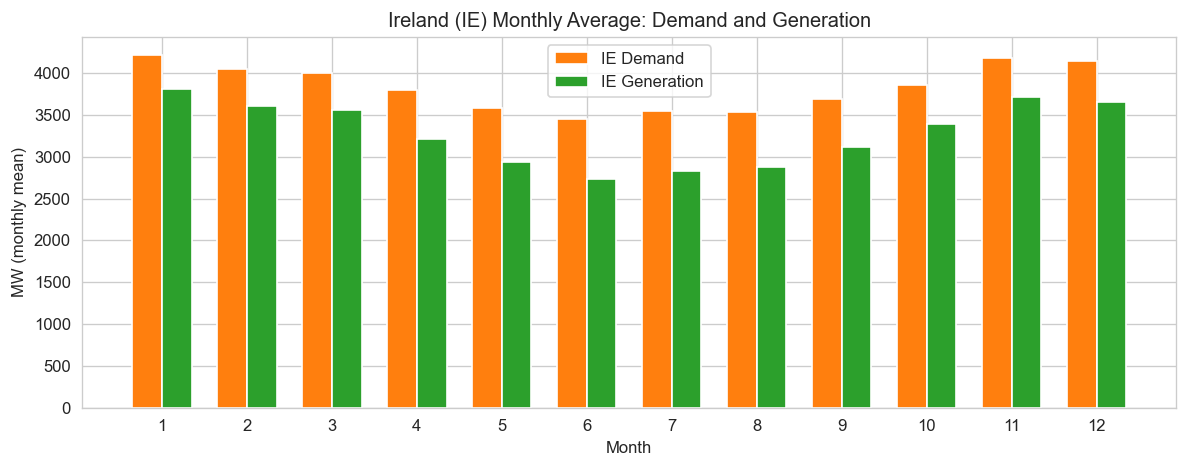

In [35]:


df["IE_Demand"] = pd.to_numeric(df.get("IE Demand", df.get("IE_Demand", np.nan)), errors="coerce")
df["IE_Generation"] = pd.to_numeric(df.get("IE Generation", df.get("IE_Generation", np.nan)), errors="coerce")

#  month column for grouping (1..12)
df["month"] = df.index.month
# Computing monthly averages (mean) for IE: Demand and Generation
ie_monthly_avg = df.groupby("month")[["IE_Demand", "IE_Generation"]].mean().reindex(range(1,13))
ie_monthly_avg.index.name = "Month"

# Plot 2: IE monthly average Demand and Generation (side-by-side bars)
fig, ax = plt.subplots(figsize=(10,4))
months = ie_monthly_avg.index
ax.bar(months - width/2, ie_monthly_avg["IE_Demand"], width=width, label="IE Demand", color="tab:orange")
ax.bar(months + width/2, ie_monthly_avg["IE_Generation"], width=width, label="IE Generation", color="tab:green")
ax.set_xticks(months)
ax.set_xticklabels([str(m) for m in months])
ax.set_xlabel("Month")
ax.set_ylabel("MW (monthly mean)")
ax.set_title("Ireland (IE) Monthly Average: Demand and Generation")
ax.legend()
plt.tight_layout()
plt.show()


In [36]:
# results for reporting
ni_monthly_avg, ie_monthly_avg

(        NI_Demand  NI_Generation
 Month                           
 1      940.092453     932.093070
 2      897.000681     908.153517
 3      854.394561     882.949722
 4      813.188407     812.331757
 5      776.154811     781.090264
 6      746.288539     779.743063
 7      735.066942     735.659039
 8      724.909972     794.683814
 9      772.296359     740.112364
 10     827.232131     840.340774
 11     904.993972     829.217667
 12     874.676317     952.402207,
          IE_Demand  IE_Generation
 Month                            
 1      4222.890017    3813.755874
 2      4057.178035    3606.282680
 3      4001.856267    3556.915859
 4      3794.158215    3218.711135
 5      3582.209432    2938.494728
 6      3449.699660    2735.874753
 7      3546.272241    2829.982735
 8      3532.057241    2873.539308
 9      3695.073611    3113.751868
 10     3861.066371    3392.631944
 11     4180.054118    3711.849771
 12     4148.181452    3657.739509)

## NI Wind & Solar Generation by Hour of Day

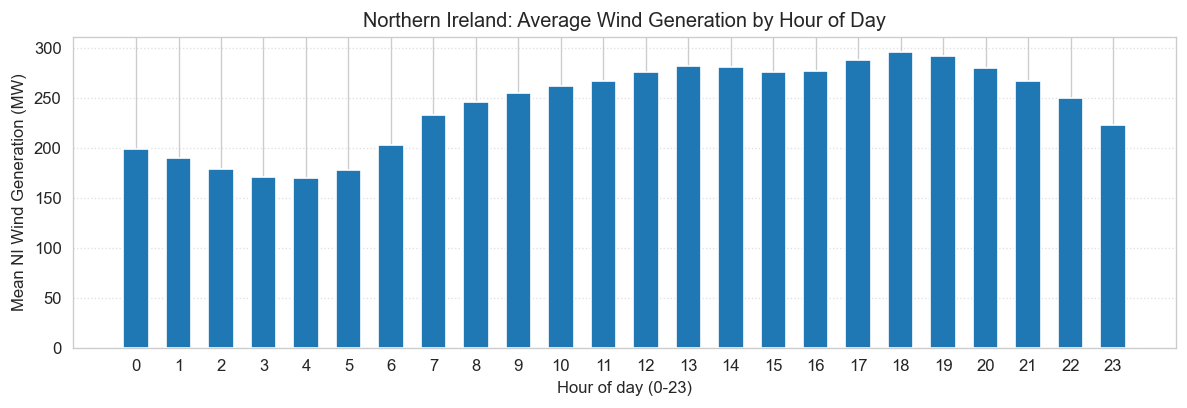

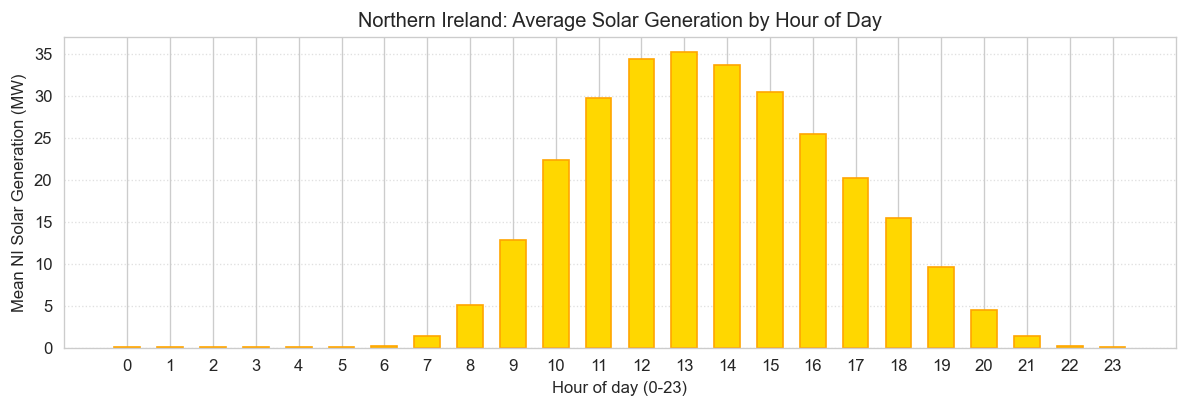

In [37]:

# Working on a local copy to avoid mutating global objects
df = cleaned_df.copy()

# Coercing expected NI wind/solar columns to numeric, creating canonical column names
df["NI_Wind"] = pd.to_numeric(df.get("NI Wind Generation", df.get("NI_Wind", np.nan)), errors="coerce")
df["NI_Solar"] = pd.to_numeric(df.get("NI Solar Generation", df.get("NI_Solar", np.nan)), errors="coerce")

# Ensuring an 'hour' column exists (0-23); create from index if missing
if "hour" not in df.columns:
    df["hour"] = df.index.hour

# Group by hour of day and compute mean for NI_Wind and NI_Solar (ignoring NaNs)
hourly_mean = df.groupby("hour")[["NI_Wind", "NI_Solar"]].mean().reindex(range(24))

# Preparing plotting defaults
plt.rcParams["figure.dpi"] = 120
width = 0.6

# Plot 1: NI Wind average by hour (bar chart)
fig, ax = plt.subplots(figsize=(10,3.5))
ax.bar(hourly_mean.index, hourly_mean["NI_Wind"], color="tab:blue", width=width)
ax.set_xticks(range(24))
ax.set_xlabel("Hour of day (0-23)")
ax.set_ylabel("Mean NI Wind Generation (MW)")
ax.set_title("Northern Ireland: Average Wind Generation by Hour of Day")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# Plot 2: NI Solar average by hour (bar chart)
fig, ax = plt.subplots(figsize=(10,3.5))
ax.bar(hourly_mean.index, hourly_mean["NI_Solar"], color="gold", width=width, edgecolor="orange")
ax.set_xticks(range(24))
ax.set_xlabel("Hour of day (0-23)")
ax.set_ylabel("Mean NI Solar Generation (MW)")
ax.set_title("Northern Ireland: Average Solar Generation by Hour of Day")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

## IE Demand & Generation by Weekday

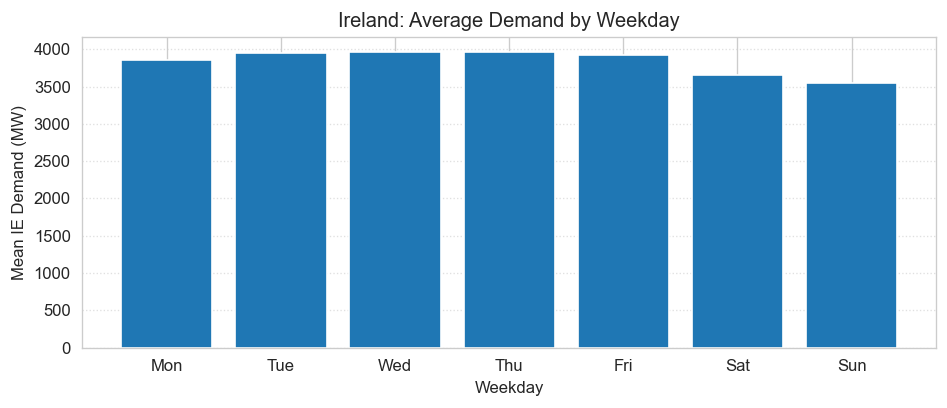

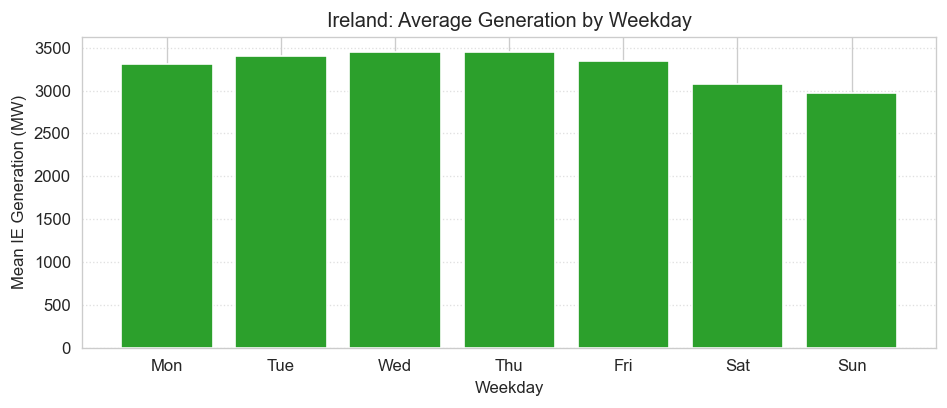

(           IE_Demand  IE_Generation
 Weekday                            
 Mon      3856.630816    3310.566484
 Tue      3952.893620    3407.732769
 Wed      3966.150389    3444.319569
 Thu      3965.671621    3451.648720
 Fri      3923.140541    3344.185533
 Sat      3657.281032    3072.786835
 Sun      3546.251172    2972.811871,
          IE_Demand  IE_Generation
 weekday                          
 Mon           5088           5088
 Tue           5088           5088
 Wed           4992           4992
 Thu           4992           4992
 Fri           4992           4992
 Sat           4992           4992
 Sun           4992           4992)

In [38]:
df = cleaned_df.copy()                            # work on a local copy to avoid mutating original

# 2. Ensuring IE demand/generation columns exist and are numeric
df["IE_Demand"] = pd.to_numeric(df.get("IE Demand", df.get("IE_Demand", np.nan)), errors="coerce")
df["IE_Generation"] = pd.to_numeric(df.get("IE Generation", df.get("IE_Generation", np.nan)), errors="coerce")

# 3. Ensuring a day-of-week indicator exists (Monday=0 .. Sunday=6)
if "dayofweek" not in df.columns:
    df["dayofweek"] = df.index.dayofweek

# 4. Mapping numeric dayofweek to weekday names for clearer plotting
weekday_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
df["weekday"] = df["dayofweek"].map(weekday_map)

# 5. Computing mean demand and mean generation grouped by weekday (preserve calendar order Mon..Sun)
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ie_weekly_avg = df.groupby("weekday")[["IE_Demand", "IE_Generation"]].mean().reindex(weekday_order)
ie_weekly_avg.index.name = "Weekday"

# 6. Also computing counts per weekday to expose sample sizes (diagnostic)
ie_weekday_counts = df.groupby("weekday")[["IE_Demand", "IE_Generation"]].count().reindex(weekday_order)

# 7. Plot 1: Average IE Demand by weekday (bar chart)
plt.rcParams["figure.dpi"] = 120
fig, ax = plt.subplots(figsize=(8,3.5))
ax.bar(ie_weekly_avg.index, ie_weekly_avg["IE_Demand"], color="tab:blue")
ax.set_xlabel("Weekday")
ax.set_ylabel("Mean IE Demand (MW)")
ax.set_title("Ireland: Average Demand by Weekday")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 8. Plot 2: Average IE Generation by weekday (bar chart)
fig, ax = plt.subplots(figsize=(8,3.5))
ax.bar(ie_weekly_avg.index, ie_weekly_avg["IE_Generation"], color="tab:green")
ax.set_xlabel("Weekday")
ax.set_ylabel("Mean IE Generation (MW)")
ax.set_title("Ireland: Average Generation by Weekday")
ax.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 9. Exposing results for reporting: weekday means and sample counts
ie_weekly_avg, ie_weekday_counts


## Daily Demand Profiles by Weekday — NI & IE

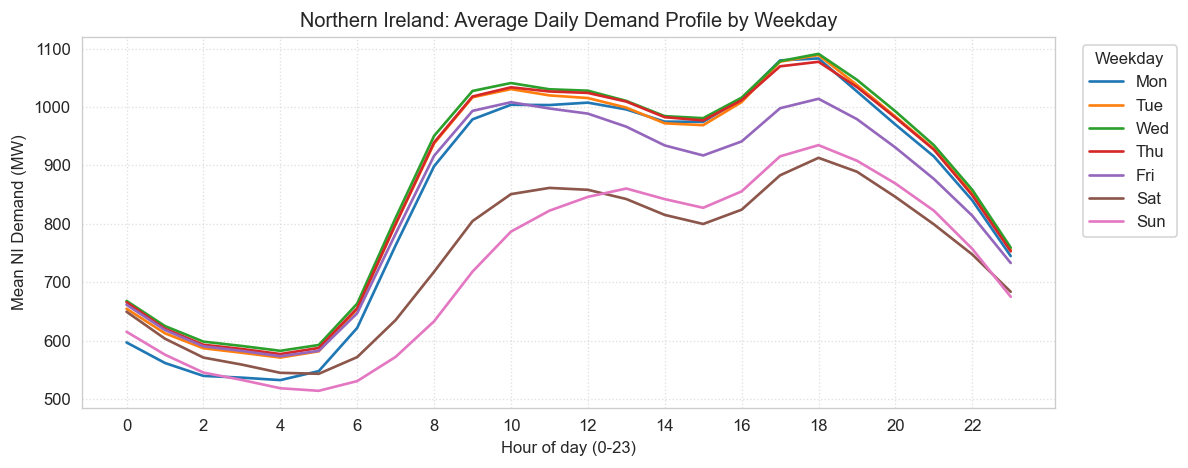

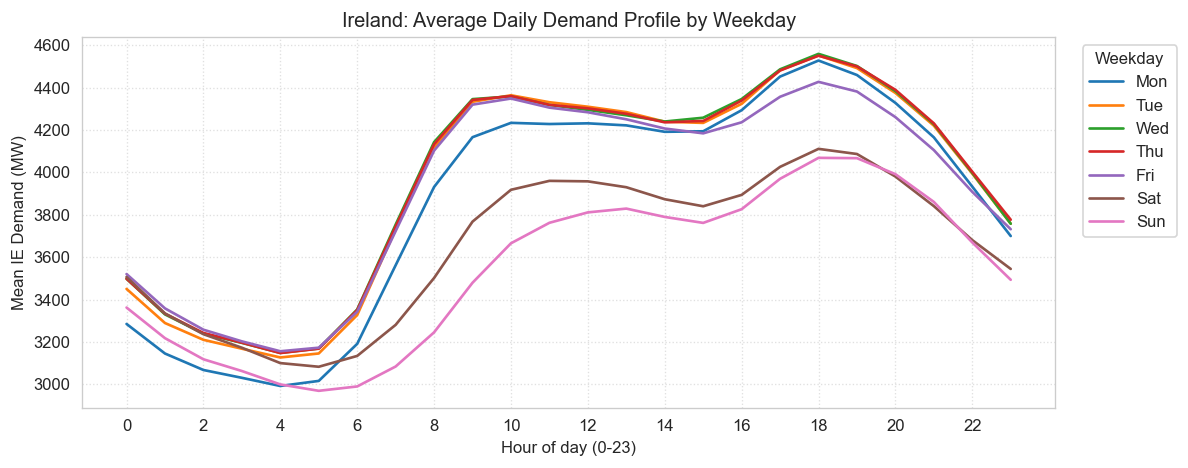

In [39]:
df = cleaned_df.copy()                              # work on a local copy to avoid mutating original

# Ensure numeric demand columns exist and coerce invalid entries to NaN
df["NI_Demand"] = pd.to_numeric(df.get("NI Demand", df.get("NI_Demand", np.nan)), errors="coerce")  # NI demand numeric
df["IE_Demand"] = pd.to_numeric(df.get("IE Demand", df.get("IE_Demand", np.nan)), errors="coerce")  # IE demand numeric

# Ensure hour and weekday indicators exist (hour: 0-23, weekday: Mon=0..Sun=6)
if "hour" not in df.columns:
    df["hour"] = df.index.hour                      # derive hour from datetime index
if "dayofweek" not in df.columns:
    df["dayofweek"] = df.index.dayofweek            # derive day-of-week from datetime index

# Map weekday numbers to short names and enforce calendar order
weekday_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
df["weekday_name"] = df["dayofweek"].map(weekday_map)  # map numeric to names
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Compute the average demand for each hour-of-day for each weekday for NI and IE
# Group by weekday_name and hour, then compute mean and unstack so rows=weekday, cols=hour
ni_grouped = df.groupby(["weekday_name", "hour"])["NI_Demand"].mean().unstack(level="hour").reindex(index=weekday_order)
ie_grouped = df.groupby(["weekday_name", "hour"])["IE_Demand"].mean().unstack(level="hour").reindex(index=weekday_order)

# Replace missing hour columns (if any) with NaN to ensure 0..23 columns exist
all_hours = list(range(24))
ni_grouped = ni_grouped.reindex(columns=all_hours)
ie_grouped = ie_grouped.reindex(columns=all_hours)

# For plotting convenience, ensure columns (hours) are in 0..23 order and convert to numeric arrays
ni_profiles = ni_grouped.loc[:, all_hours]
ie_profiles = ie_grouped.loc[:, all_hours]

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# Plot 1: NI daily demand profiles (one curve per weekday)
fig, ax = plt.subplots(figsize=(10, 4))
for weekday in ni_profiles.index:
    ax.plot(all_hours, ni_profiles.loc[weekday].values, label=weekday, linewidth=1.6)  # plot weekday curve
ax.set_xticks(range(0, 24, 2))                       # tick every 2 hours
ax.set_xlabel("Hour of day (0-23)")
ax.set_ylabel("Mean NI Demand (MW)")
ax.set_title("Northern Ireland: Average Daily Demand Profile by Weekday")
ax.legend(title="Weekday", bbox_to_anchor=(1.02, 1), loc="upper left")  # legend outside plot
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# Plot 2: IE daily demand profiles (one curve per weekday)
fig, ax = plt.subplots(figsize=(10, 4))
for weekday in ie_profiles.index:
    ax.plot(all_hours, ie_profiles.loc[weekday].values, label=weekday, linewidth=1.6)  # plot weekday curve
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day (0-23)")
ax.set_ylabel("Mean IE Demand (MW)")
ax.set_title("Ireland: Average Daily Demand Profile by Weekday")
ax.legend(title="Weekday", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


## Weekend vs Weekday: Demand & Solar (Statistical Tests)

In [40]:

df = cleaned_df.copy()                            # work on a copy to avoid mutating original

# Prepare numeric series for Demand and Solar for NI and IE (coerce non-numeric to NaN)
df["NI_Demand"] = pd.to_numeric(df.get("NI Demand", df.get("NI_Demand", np.nan)), errors="coerce")
df["IE_Demand"] = pd.to_numeric(df.get("IE Demand", df.get("IE_Demand", np.nan)), errors="coerce")
df["NI_Solar"] = pd.to_numeric(df.get("NI Solar Generation", df.get("NI_Solar", np.nan)), errors="coerce")
df["IE_Solar"] = pd.to_numeric(df.get("IE Solar Generation", df.get("IE_Solar", np.nan)), errors="coerce")

# Ensure day-of-week indicator exists (Monday=0 .. Sunday=6)
if "dayofweek" not in df.columns:
    df["dayofweek"] = df.index.dayofweek

# Create boolean masks for weekend (Sat=5, Sun=6) and weekday (Mon-Fri = 0-4)
weekend_mask = df["dayofweek"].isin([5, 6])
weekday_mask = df["dayofweek"].isin([0, 1, 2, 3, 4])

# Helper: extract two independent samples (drop NaNs)
def samples_for(column):
    weekend = df.loc[weekend_mask, column].dropna().values
    weekday = df.loc[weekday_mask, column].dropna().values
    return weekend, weekday

# Prepare samples
ni_d_weekend, ni_d_weekday = samples_for("NI_Demand")
ie_d_weekend, ie_d_weekday = samples_for("IE_Demand")
ni_s_weekend, ni_s_weekday = samples_for("NI_Solar")
ie_s_weekend, ie_s_weekday = samples_for("IE_Solar")

# Function to run Welch's t-test (unequal variances) and return test statistic and p-value
def welch_ttest(a, b):
    # If one of the samples is empty, return NaNs
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    tstat, pval = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    return float(tstat), float(pval)

# Function to run Mann-Whitney U test (nonparametric) and return statistic and p-value
def mannwhitney(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan
    # use alternative='two-sided'
    stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return float(stat), float(p)

# Run tests for each case and record means and sample sizes
results = {}

# NI Demand
results["NI_Demand"] = {
    "weekend_mean": float(np.nanmean(ni_d_weekend)) if len(ni_d_weekend)>0 else np.nan,
    "weekday_mean": float(np.nanmean(ni_d_weekday)) if len(ni_d_weekday)>0 else np.nan,
    "n_weekend": int(len(ni_d_weekend)),
    "n_weekday": int(len(ni_d_weekday)),
    "welch_tstat": None,
    "welch_pval": None,
    "mw_stat": None,
    "mw_pval": None
}
results["NI_Demand"]["welch_tstat"], results["NI_Demand"]["welch_pval"] = welch_ttest(ni_d_weekend, ni_d_weekday)
results["NI_Demand"]["mw_stat"], results["NI_Demand"]["mw_pval"] = mannwhitney(ni_d_weekend, ni_d_weekday)

# IE Demand
results["IE_Demand"] = {
    "weekend_mean": float(np.nanmean(ie_d_weekend)) if len(ie_d_weekend)>0 else np.nan,
    "weekday_mean": float(np.nanmean(ie_d_weekday)) if len(ie_d_weekday)>0 else np.nan,
    "n_weekend": int(len(ie_d_weekend)),
    "n_weekday": int(len(ie_d_weekday)),
    "welch_tstat": None,
    "welch_pval": None,
    "mw_stat": None,
    "mw_pval": None
}
results["IE_Demand"]["welch_tstat"], results["IE_Demand"]["welch_pval"] = welch_ttest(ie_d_weekend, ie_d_weekday)
results["IE_Demand"]["mw_stat"], results["IE_Demand"]["mw_pval"] = mannwhitney(ie_d_weekend, ie_d_weekday)

# NI Solar
results["NI_Solar"] = {
    "weekend_mean": float(np.nanmean(ni_s_weekend)) if len(ni_s_weekend)>0 else np.nan,
    "weekday_mean": float(np.nanmean(ni_s_weekday)) if len(ni_s_weekday)>0 else np.nan,
    "n_weekend": int(len(ni_s_weekend)),
    "n_weekday": int(len(ni_s_weekday)),
    "welch_tstat": None,
    "welch_pval": None,
    "mw_stat": None,
    "mw_pval": None
}
results["NI_Solar"]["welch_tstat"], results["NI_Solar"]["welch_pval"] = welch_ttest(ni_s_weekend, ni_s_weekday)
results["NI_Solar"]["mw_stat"], results["NI_Solar"]["mw_pval"] = mannwhitney(ni_s_weekend, ni_s_weekday)

# IE Solar
results["IE_Solar"] = {
    "weekend_mean": float(np.nanmean(ie_s_weekend)) if len(ie_s_weekend)>0 else np.nan,
    "weekday_mean": float(np.nanmean(ie_s_weekday)) if len(ie_s_weekday)>0 else np.nan,
    "n_weekend": int(len(ie_s_weekend)),
    "n_weekday": int(len(ie_s_weekday)),
    "welch_tstat": None,
    "welch_pval": None,
    "mw_stat": None,
    "mw_pval": None
}
results["IE_Solar"]["welch_tstat"], results["IE_Solar"]["welch_pval"] = welch_ttest(ie_s_weekend, ie_s_weekday)
results["IE_Solar"]["mw_stat"], results["IE_Solar"]["mw_pval"] = mannwhitney(ie_s_weekend, ie_s_weekday)

# Exposing results: results dict containing test statistics and p-values
results

{'NI_Demand': {'weekend_mean': 735.3881944110577,
  'weekday_mean': 856.2662024888676,
  'n_weekend': 9984,
  'n_weekday': 25152,
  'welch_tstat': -57.695952651396745,
  'welch_pval': 0.0,
  'mw_stat': 83288214.5,
  'mw_pval': 0.0},
 'IE_Demand': {'weekend_mean': 3601.766101762821,
  'weekday_mean': 3932.6826248409666,
  'n_weekend': 9984,
  'n_weekday': 25152,
  'welch_tstat': -54.997517331888005,
  'welch_pval': 0.0,
  'mw_stat': 84910420.5,
  'mw_pval': 0.0},
 'NI_Solar': {'weekend_mean': 11.874834635416667,
  'weekday_mean': 11.738741889312978,
  'n_weekend': 9984,
  'n_weekday': 25152,
  'welch_tstat': 0.5518344002573795,
  'welch_pval': 0.5810688041799088,
  'mw_stat': 125432280.5,
  'mw_pval': 0.875001009280581},
 'IE_Solar': {'weekend_mean': 74.20273637820513,
  'weekday_mean': 75.35434438613231,
  'n_weekend': 9984,
  'n_weekday': 25152,
  'welch_tstat': -0.7954270337060876,
  'welch_pval': 0.42637541979763616,
  'mw_stat': 126158192.0,
  'mw_pval': 0.4834188043390307}}

## Wind Penetration Rate Distribution — NI & IE

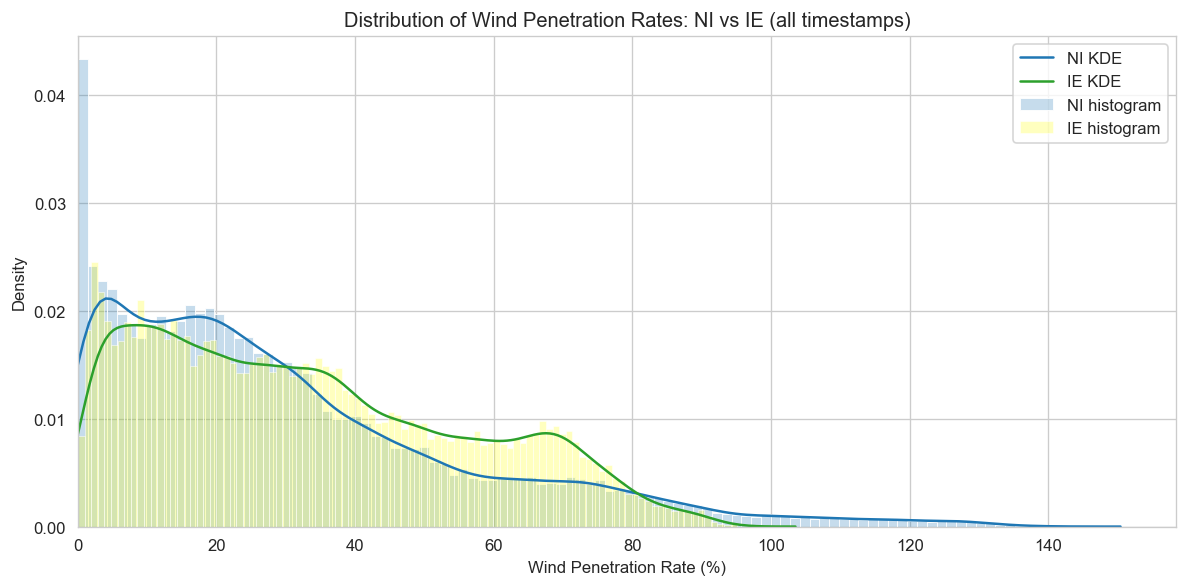

{'NI_median': 23.580664549095925,
 'NI_95th_pct': 82.92249916941498,
 'IE_median': 29.407049120633886,
 'IE_95th_pct': 74.00005706824516,
 'NI_count': 35136,
 'IE_count': 35136}

In [41]:
df = cleaned_df.copy()                          # work on a local copy to avoid mutating original

# 1. Ensure numeric wind generation and demand columns exist; coerce non-numeric to NaN
df["NI_Wind"] = pd.to_numeric(df.get("NI Wind Generation", df.get("NI_Wind", np.nan)), errors="coerce")
df["NI_Demand"] = pd.to_numeric(df.get("NI Demand", df.get("NI_Demand", np.nan)), errors="coerce")
df["IE_Wind"] = pd.to_numeric(df.get("IE Wind Generation", df.get("IE_Wind", np.nan)), errors="coerce")
df["IE_Demand"] = pd.to_numeric(df.get("IE Demand", df.get("IE_Demand", np.nan)), errors="coerce")

# 2. Compute wind penetration rate (%) at each timestamp; avoid division by zero and handle NaNs
#    penetration = (wind / demand) * 100
df["NI_Wind_Penetration"] = (df["NI_Wind"] / df["NI_Demand"]) * 100
df["IE_Wind_Penetration"] = (df["IE_Wind"] / df["IE_Demand"]) * 100

# 3. Replace infinite values (from division by zero) with NaN and drop impossible negatives if any
df["NI_Wind_Penetration"].replace([np.inf, -np.inf], np.nan, inplace=True)
df["IE_Wind_Penetration"].replace([np.inf, -np.inf], np.nan, inplace=True)
df["NI_Wind_Penetration"] = df["NI_Wind_Penetration"].mask(df["NI_Wind_Penetration"] < 0, np.nan)
df["IE_Wind_Penetration"] = df["IE_Wind_Penetration"].mask(df["IE_Wind_Penetration"] < 0, np.nan)

# 4. Compute summary statistics to annotate the plot
ni_stats = df["NI_Wind_Penetration"].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_dict()
ie_stats = df["IE_Wind_Penetration"].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).to_dict()

# 5. Prepare the plotting area: overlayed KDE + histogram for comparison on the same axes
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10,5))

# 6. Plot NI distribution: KDE and semi-transparent histogram
sns.histplot(df["NI_Wind_Penetration"].dropna(), bins=100, color="tab:blue", stat="density", alpha=0.25, label="NI histogram", ax=ax)
sns.kdeplot(df["NI_Wind_Penetration"].dropna(), color="tab:blue", linewidth=1.5, label="NI KDE", ax=ax)

# 7. Plot IE distribution: KDE and semi-transparent histogram
sns.histplot(df["IE_Wind_Penetration"].dropna(), bins=100, color="Yellow", stat="density", alpha=0.25, label="IE histogram", ax=ax)
sns.kdeplot(df["IE_Wind_Penetration"].dropna(), color="tab:green", linewidth=1.5, label="IE KDE", ax=ax)

# 8. Axis labels, title, legend, and layout
ax.set_xlabel("Wind Penetration Rate (%)")
ax.set_ylabel("Density")
ax.set_title("Distribution of Wind Penetration Rates: NI vs IE (all timestamps)")
ax.legend()
ax.set_xlim(left=0)                          # penetration < 0 are removed; focus on non-negative
plt.tight_layout()
plt.show()

# 9. Expose key summary percentiles (median and selected percentiles) for reporting
summary = {
    "NI_median": float(ni_stats.get("50%")) if ni_stats.get("50%") is not None else np.nan,
    "NI_95th_pct": float(ni_stats.get("95%")) if ni_stats.get("95%") is not None else np.nan,
    "IE_median": float(ie_stats.get("50%")) if ie_stats.get("50%") is not None else np.nan,
    "IE_95th_pct": float(ie_stats.get("95%")) if ie_stats.get("95%") is not None else np.nan,
    "NI_count": int(df["NI_Wind_Penetration"].count()),
    "IE_count": int(df["IE_Wind_Penetration"].count())
}
summary
